In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [48]:
# importing the dataset
df_main=pd.read_csv('data.csv',encoding="latin-1")
df=df_main.copy()  #creating a copy of the dataset to work on

In [49]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [50]:
df.shape

(541909, 8)

# **Data cleaning**

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [52]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])

In [53]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [54]:
df.isnull().sum()  #checking for null values

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [55]:
df=df[~df["CustomerID"].isnull()]  #Extracting rows where CustomerID is not null

In [56]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [57]:
df["Total_amount"]=df["Quantity"]*df["UnitPrice"]  #creating a new column for total amount spent by each customer

In [58]:
df.drop(columns=["Description"],inplace=True)  #dropping unnecessary columns

In [59]:
df.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_amount
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# **Basic analysis**

In [60]:
round(df["Total_amount"].sum(),2) #total sales

np.float64(8300065.81)

In [ ]:
round(df["Quantity"].sum(),2) #total quantity sold

np.int64(4906888)

In [62]:
round(df["Total_amount"].sum()/df["InvoiceDate"].nunique(),2) #average sales per day


np.float64(405.67)

In [63]:
df["Month"]=df["InvoiceDate"].dt.month  #creating a new column for month

Text(0, 0.5, 'Total Sales')

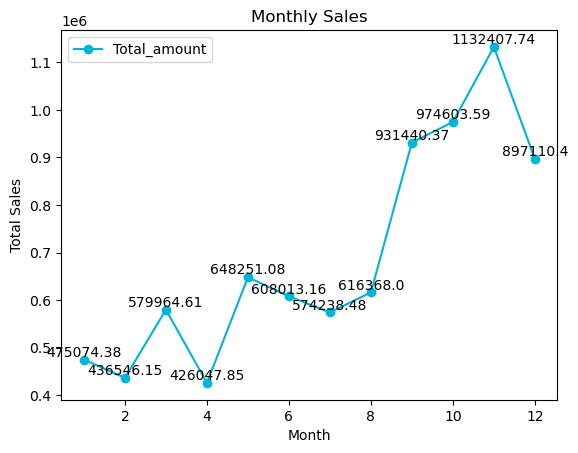

In [64]:
monthly_sales=df.groupby("Month").agg({"Total_amount": "sum"})  #total sales per month
monthly_sales.plot(kind="line",color="#00b4d8",marker="o")

for i in range(1,13):
    plt.text(i,monthly_sales["Total_amount"][i],round(monthly_sales["Total_amount"][i],2),ha="center",va="bottom",color="black")


plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")


In [89]:
df.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID,Total_amount,Month
count,406829.000000,406829,406829.000000,406829.000000,406829.000000,406829.000000
mean,12.061303,2011-07-10 16:30:57.879207424,3.460471,15287.690570,20.401854,7.605947
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,-168469.600000,1.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13953.000000,4.200000,5.000000
50%,5.000000,2011-07-31 11:48:00,1.950000,15152.000000,11.100000,8.000000
75%,12.000000,2011-10-20 13:06:00,3.750000,16791.000000,19.500000,11.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000,12.000000
std,248.693370,NaN,69.315162,1713.600303,427.591718,3.418942


C:\Users\Niloy\AppData\Local\Temp\ipykernel_9012\2598503725.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i,country_wise_sales["Total_amount"][i],round(country_wise_sales["Total_amount"][i],2),ha="center",va="bottom",color="black")


Text(0, 0.5, 'Total Sales')

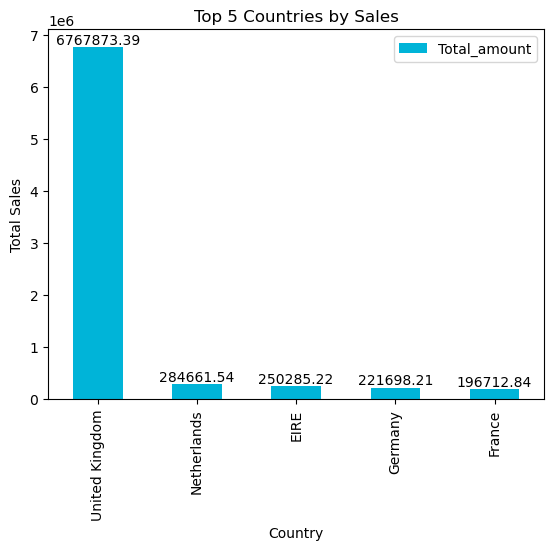

In [65]:
country_wise_sales=df.groupby("Country").agg({"Total_amount": "sum"}).sort_values("Total_amount",ascending=False).head(5   )  #total sales per country
country_wise_sales.plot(kind="bar",color="#00b4d8")

for i in range(len(country_wise_sales)):
    plt.text(i,country_wise_sales["Total_amount"][i],round(country_wise_sales["Total_amount"][i],2),ha="center",va="bottom",color="black")

plt.title("Top 5 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")


# **Customer wise analysis**

In [66]:
Customer_details=df.groupby("CustomerID")["Total_amount"].sum().sort_values(ascending=False).reset_index()
Customer_details["Status"]=Customer_details["Total_amount"].apply(lambda x: "Net returner" if x<=0 else "Valid")  #creating a new column to classify customers based on total amount spent

Text(0, 0.5, '')

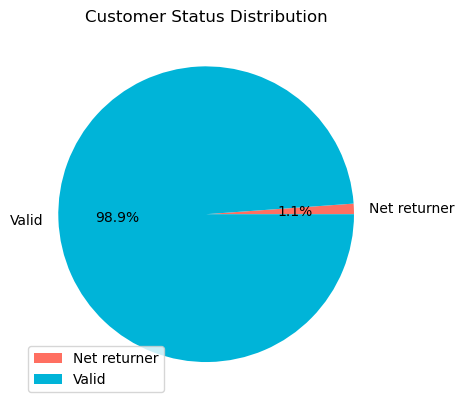

In [67]:
Status_wise=Customer_details.groupby("Status")["CustomerID"].count().reset_index() #counting the number of valid and net returner customers
Status_wise.plot(kind="pie",y="CustomerID",labels=Status_wise["Status"],autopct="%1.1f%%",colors=["#ff6f61","#00b4d8"])
plt.title("Customer Status Distribution")
plt.ylabel("")

Now extracating actual customers who are valid

In [68]:
Valid_customers = Customer_details[Customer_details["Status"]=="Valid"] #Extracting rows where customers are valid

In [69]:
# getting the list of valid customers
valid_customer_list=Valid_customers["CustomerID"].tolist()

In [70]:
# now we will filter the original dataset to include only valid customers
df_valid=df[df["CustomerID"].isin(valid_customer_list)]

In [71]:
df_valid.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_amount,Month
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12


removing the cancellation transactions

In [72]:
df_valid = df_valid[~df_valid['InvoiceNo'].str.startswith('C')]

Now the final data set

In [73]:
df_valid

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_amount,Month
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12
541905,581587,22899,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12
541906,581587,23254,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12
541907,581587,23255,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12


In [74]:
df_valid.drop(columns=["StockCode"],inplace=True)

In [75]:
df_valid

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_amount,Month
0,536365,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12
3,536365,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
4,536365,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
...,...,...,...,...,...,...,...,...
541904,581587,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12
541905,581587,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12
541906,581587,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12
541907,581587,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12


## **RFM analysis**

| Metric            | Meaning                         |
| ----------------- | ------------------------------- |
| **R (Recency)**   | How recently customer purchased |
| **F (Frequency)** | How often customer purchased    |
| **M (Monetary)**  | How much money customer spent   |


Recency

In [76]:
snapshot_date=df_valid["InvoiceDate"].max()+pd.DateOffset(days=1) #setting the snapshot date as one day after the last invoice date in the dataset

In [77]:
rfm = df_valid.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary  = ('Total_amount', 'sum')
).reset_index()


In [78]:
rfm

,CustomerID,Recency,Frequency,Monetary
0,12347.0,2,7,4310.00
1,12348.0,75,4,1797.24
2,12349.0,19,1,1757.55
3,12350.0,310,1,334.40
4,12352.0,36,8,2506.04
...,...,...,...,...
4317,18280.0,278,1,180.60
4318,18281.0,181,1,80.82
4319,18282.0,8,2,178.05
4320,18283.0,4,16,2094.88


In [79]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4322 entries, 0 to 4321
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4322 non-null   float64
 1   Recency     4322 non-null   int64  
 2   Frequency   4322 non-null   int64  
 3   Monetary    4322 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 135.2 KB


In [80]:
rfm

,CustomerID,Recency,Frequency,Monetary
0,12347.0,2,7,4310.00
1,12348.0,75,4,1797.24
2,12349.0,19,1,1757.55
3,12350.0,310,1,334.40
4,12352.0,36,8,2506.04
...,...,...,...,...
4317,18280.0,278,1,180.60
4318,18281.0,181,1,80.82
4319,18282.0,8,2,178.05
4320,18283.0,4,16,2094.88


In [81]:
# Score each metric (3 = best, 1 = worst)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=3, labels=[3,2,1])  # flipped — low recency = best
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=3, labels=[1,2,3])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=3, labels=[1,2,3])

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Total RFM score (range: 3 to 9)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Label into 3 tiers
rfm['Customer_Segment'] = pd.cut(rfm['RFM_Score'],
    bins=[2, 5, 7, 9],
    labels=['Low Value', 'Mid Value', 'High Value']
)

In [82]:
rfm

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
0,12347.0,2,7,4310.00,3,3,3,9,High Value
1,12348.0,75,4,1797.24,2,2,3,7,Mid Value
2,12349.0,19,1,1757.55,3,1,3,7,Mid Value
3,12350.0,310,1,334.40,1,1,1,3,Low Value
4,12352.0,36,8,2506.04,2,3,3,8,High Value
...,...,...,...,...,...,...,...,...,...
4317,18280.0,278,1,180.60,1,2,1,4,Low Value
4318,18281.0,181,1,80.82,1,2,1,4,Low Value
4319,18282.0,8,2,178.05,3,2,1,6,Mid Value
4320,18283.0,4,16,2094.88,3,3,3,9,High Value


C:\Users\Niloy\AppData\Local\Temp\ipykernel_9012\1695433508.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i,rfm_segment[i],rfm_segment[i],ha="center",va="bottom",color="black")


Text(0, 0.5, 'Number of Customers')

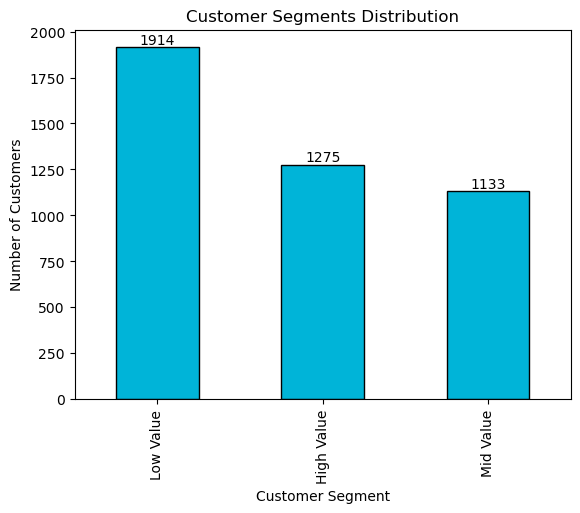

In [83]:
rfm_segment=rfm["Customer_Segment"].value_counts()
rfm_segment.plot(kind="bar",color="#00b4d8",edgecolor="black")
plt.title("Customer Segments Distribution") 
for i in range(len(rfm_segment)):
    plt.text(i,rfm_segment[i],rfm_segment[i],ha="center",va="bottom",color="black")

plt.title("Customer Segments Distribution")
plt.xlabel("Customer Segment")  
plt.ylabel("Number of Customers")

# **merging rfm to df_valid to analyze the distribution of customers across different countries based on their RFM scores**


In [84]:
rfm_merged=pd.merge(rfm,df_valid[["CustomerID","Country"]],on="CustomerID",how="left")
rfm_merged.drop_duplicates(subset=["CustomerID"],inplace=True)

In [85]:
rfm_merged

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment,Country
0,12347.0,2,7,4310.00,3,3,3,9,High Value,Iceland
182,12348.0,75,4,1797.24,2,2,3,7,Mid Value,Finland
213,12349.0,19,1,1757.55,3,1,3,7,Mid Value,Italy
286,12350.0,310,1,334.40,1,1,1,3,Low Value,Norway
303,12352.0,36,8,2506.04,2,3,3,8,High Value,Norway
...,...,...,...,...,...,...,...,...,...,...
396960,18280.0,278,1,180.60,1,2,1,4,Low Value,United Kingdom
396970,18281.0,181,1,80.82,1,2,1,4,Low Value,United Kingdom
396977,18282.0,8,2,178.05,3,2,1,6,Mid Value,United Kingdom
396989,18283.0,4,16,2094.88,3,3,3,9,High Value,United Kingdom


In [86]:
# country wise differenct type of customer type
country_wises_customer_type=rfm_merged.groupby(["Country", "Customer_Segment"])["CustomerID"].count().reset_index()

C:\Users\Niloy\AppData\Local\Temp\ipykernel_9012\3579401655.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_wises_customer_type=rfm_merged.groupby(["Country", "Customer_Segment"])["CustomerID"].count().reset_index()


In [ ]:
# Data for management of customer distribution across countries and segments
country_wise_customer_distribution_file=country_wises_customer_type.pivot(index='Country', columns='Customer_Segment', values='CustomerID') #pivoting the data to get the count of each customer segment for each country

In [88]:
# Step 1 - count customers per country and segment
segment_country = rfm_merged.groupby(['Customer_Segment', 'Country']).size().reset_index(name='Customer_Count')

# Step 2 - keep top 5 countries per segment
top5 = (segment_country
        .sort_values(['Customer_Segment', 'Customer_Count'], ascending=[True, False])
        .groupby('Customer_Segment')
        .head(5))

top5

C:\Users\Niloy\AppData\Local\Temp\ipykernel_9012\1002400024.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_country = rfm_merged.groupby(['Customer_Segment', 'Country']).size().reset_index(name='Customer_Count')
C:\Users\Niloy\AppData\Local\Temp\ipykernel_9012\1002400024.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Customer_Segment')


,Customer_Segment,Country,Customer_Count
35,Low Value,United Kingdom,1743
13,Low Value,France,35
14,Low Value,Germany,33
30,Low Value,Spain,12
26,Low Value,Portugal,8
72,Mid Value,United Kingdom,1013
51,Mid Value,Germany,28
50,Mid Value,France,22
67,Mid Value,Spain,10
69,Mid Value,Switzerland,10


# **Data for management**

In [93]:
country_wise_customer_distribution_file #country wise customer distribution across segments
country_wise_customer_distribution_file.to_csv("country_wise_customer_distribution.csv",index=True) #saving the file for management use

In [98]:
customer_data_base=rfm[["CustomerID","Customer_Segment"]] #in this data base we have the customer id and their corresponding segment which can be used for future marketing campaigns and customer analysis
customer_data_base.to_csv("customer_data_base.csv",index=False) #saving the file for